# Week 1 - Data Acquisition, Cleaning and Exploratory Analysis

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns), from IBM's
`telco-customer-churn-on-icp4d` repository (Apache 2.0).

This notebook runs the three Week 1 scripts in order - acquisition, cleaning and
EDA - and shows their outputs. The code cells are taken directly from `src/`.


In [1]:
import sys
sys.path.insert(0, "../src")  # make the project modules in src/ importable
%config InlineBackend.figure_format = 'retina'

## Part 1 - Data acquisition

The IBM Telco Customer Churn dataset is published by IBM as part of the
`telco-customer-churn-on-icp4d` Code Pattern on GitHub under the Apache 2.0
licence. The CSV is downloaded straight from the repository's raw URL, its
SHA-256 checksum is recorded (and checked on later runs), and the licence
text is saved next to the data because Apache 2.0 requires it to travel with
redistributed copies.

In [2]:
import hashlib
import json

import pandas as pd
import requests
from IPython.display import display

from config import (DATASET_URL, EXPECTED_SHA256, LICENSE_PATH, LICENSE_URL,
                    PROJECT_ROOT, RAW_DATA_PATH, RESULTS_DIR, SOURCE_REPOSITORY)


def download_file(url, destination, timeout=60):
    """Download a file over HTTPS and write it to ``destination``."""
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    destination.write_bytes(response.content)
    return destination


def sha256_of(path):
    """Return the SHA-256 hex digest of a file (used to verify the download)."""
    return hashlib.sha256(path.read_bytes()).hexdigest()

In [3]:
# Download the dataset only if it is not already present locally
if RAW_DATA_PATH.exists():
    print(f"Found existing file: {RAW_DATA_PATH.relative_to(PROJECT_ROOT)}")
else:
    download_file(DATASET_URL, RAW_DATA_PATH)
    print(f"Downloaded {DATASET_URL}")

if not LICENSE_PATH.exists():
    download_file(LICENSE_URL, LICENSE_PATH)

checksum = sha256_of(RAW_DATA_PATH)
if EXPECTED_SHA256 is not None and checksum != EXPECTED_SHA256:
    raise ValueError("Checksum mismatch: the source file has changed since this project was run.")

df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"File size : {RAW_DATA_PATH.stat().st_size:,} bytes")
print(f"SHA-256   : {checksum}")
print(f"Rows      : {df_raw.shape[0]:,}")
print(f"Columns   : {df_raw.shape[1]}")
# First rows, first eight columns (the full inspection is in Part 2)
display(df_raw.head(3).iloc[:, :8])

Found existing file: data/raw/Telco-Customer-Churn.csv
File size : 970,457 bytes
SHA-256   : 16320c9c1ec72448db59aa0a26a0b95401046bef5d02fd3aeb906448e3055e91
Rows      : 7,043
Columns   : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service
1,5575-GNVDE,Male,0,No,No,34,Yes,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No


In [4]:
# Record acquisition metadata so the report and later weeks can cite exact figures
acquisition_log = {
    "dataset_name": "IBM Telco Customer Churn",
    "source_repository": SOURCE_REPOSITORY,
    "download_url": DATASET_URL,
    "license": "Apache License 2.0",
    "file_name": RAW_DATA_PATH.name,
    "file_size_bytes": RAW_DATA_PATH.stat().st_size,
    "sha256": checksum,
    "n_rows": int(df_raw.shape[0]),
    "n_columns": int(df_raw.shape[1]),
    "columns": list(df_raw.columns),
}
with open(RESULTS_DIR / "acquisition_log.json", "w") as f:
    json.dump(acquisition_log, f, indent=2)
print("Saved outputs/results/acquisition_log.json")

Saved outputs/results/acquisition_log.json


## Part 2 - Initial inspection, data quality assessment and cleaning

The raw file is inspected before anything is changed. Each cleaning decision
below is based on something found during inspection, and every change is
logged so the before/after state can be reported.

In [5]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from config import CLEAN_DATA_PATH, RAW_DATA_PATH, RESULTS_DIR, TABLE_DIR
from data_utils import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS
from plot_style import CHURN_COLOR, GRID_COLOR, MUTED_INK, apply_style, save_figure

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
apply_style()

df_raw = pd.read_csv(RAW_DATA_PATH)
cleaning_log = {"raw_shape": list(df_raw.shape)}

### 2.1 First look at the raw data

In [6]:
print("Shape (rows, columns):", df_raw.shape)
# head() shown in three column blocks so all 21 columns stay readable
for block in (slice(0, 7), slice(7, 14), slice(14, 21)):
    display(df_raw.head().iloc[:, block])

Shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService
0,7590-VHVEG,Female,0,Yes,No,1,No
1,5575-GNVDE,Male,0,No,No,34,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes
3,7795-CFOCW,Male,0,No,No,45,No
4,9237-HQITU,Female,0,No,No,2,Yes


,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV
0,No phone service,DSL,No,Yes,No,No,No
1,No,DSL,Yes,No,Yes,No,No
2,No,DSL,Yes,Yes,No,No,No
3,No phone service,DSL,Yes,No,Yes,Yes,No
4,No,Fiber optic,No,No,No,No,No


,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,No,One year,No,Mailed check,56.95,1889.5,No
2,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
for block in (slice(0, 7), slice(7, 14), slice(14, 21)):
    display(df_raw.tail().iloc[:, block])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes
7040,4801-JZAZL,Female,0,Yes,Yes,11,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes


,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV
7038,Yes,DSL,Yes,No,Yes,Yes,Yes
7039,Yes,Fiber optic,No,Yes,Yes,No,Yes
7040,No phone service,DSL,Yes,No,No,No,No
7041,Yes,Fiber optic,No,No,No,No,No
7042,No,Fiber optic,Yes,No,Yes,Yes,Yes


,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
print(df_raw.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
display(df_raw.dtypes.value_counts().rename("number_of_columns").to_frame())

,number_of_columns
str,18
int64,2
float64,1


In [11]:
# Only three columns are numeric in the raw file - TotalCharges is missing
# from this summary because it was read as text.
display(df_raw.describe().round(2))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [12]:
display(df_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Unique values and category frequencies

In [13]:
unique_summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "sample_values": [", ".join(map(str, df_raw[c].unique()[:4])) for c in df_raw.columns],
})
display(unique_summary)
unique_summary.to_csv(TABLE_DIR / "unique_values_summary.csv")

,dtype,n_unique,sample_values
customerID,str,7043,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW"
gender,str,2,"Female, Male"
SeniorCitizen,int64,2,"0, 1"
Partner,str,2,"Yes, No"
Dependents,str,2,"No, Yes"
tenure,int64,73,"1, 34, 2, 45"
PhoneService,str,2,"No, Yes"
MultipleLines,str,3,"No phone service, No, Yes"
InternetService,str,3,"DSL, Fiber optic, No"
OnlineSecurity,str,3,"No, Yes, No internet service"


In [14]:
key_categoricals = ["Churn", "Contract", "InternetService", "PaymentMethod"]
for column in key_categoricals:
    counts = df_raw[column].value_counts()
    display(pd.DataFrame({"count": counts,
                          "percent": (counts / len(df_raw) * 100).round(2)}))

,count,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


,count,percent
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


,count,percent
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67


,count,percent
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


### 2.3 Missing values

`isna()` only counts true NaN values. Text columns can also hide missing
data as empty strings, so both are checked.

In [15]:
def missing_summary(frame):
    """Missing count and percentage for every column."""
    return pd.DataFrame({
        "missing_count": frame.isna().sum(),
        "missing_pct": (frame.isna().mean() * 100).round(3),
    })


print("NaN cells in raw data:", int(df_raw.isna().sum().sum()))

text_columns = df_raw.select_dtypes(exclude="number").columns
blank_strings = {c: int(df_raw[c].str.strip().eq("").sum()) for c in text_columns}
blank_strings = {c: n for c, n in blank_strings.items() if n > 0}
print("Columns containing blank strings:", blank_strings)

# Which TotalCharges values cannot be read as numbers?
converted = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
print("Non-numeric TotalCharges values:", df_raw.loc[converted.isna(), "TotalCharges"].unique().tolist())

NaN cells in raw data: 0
Columns containing blank strings: {'TotalCharges': 11}
Non-numeric TotalCharges values: [' ']


In [16]:
# Convert TotalCharges to a number; the blank strings become NaN
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip().replace("", np.nan))

missing_after_conversion = missing_summary(df)
display(missing_after_conversion[missing_after_conversion["missing_count"] > 0])

,missing_count,missing_pct
TotalCharges,11,0.156


In [17]:
# Is missingness related to anything? Compare with tenure.
zero_tenure = df["tenure"].eq(0)
display(pd.crosstab(zero_tenure.rename("tenure == 0"),
                    df["TotalCharges"].isna().rename("TotalCharges missing")))
missing_rows = df.loc[df["TotalCharges"].isna(),
                      ["customerID", "tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]]
display(missing_rows)

TotalCharges missing,False,True
tenure == 0,,
False,7032,0
True,0,11


,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,NaN,No
753,3115-CZMZD,0,Two year,20.25,NaN,No
936,5709-LVOEQ,0,Two year,80.85,NaN,No
1082,4367-NUYAO,0,Two year,25.75,NaN,No
1340,1371-DWPAZ,0,Two year,56.05,NaN,No
3331,7644-OMVMY,0,Two year,19.85,NaN,No
3826,3213-VVOLG,0,Two year,25.35,NaN,No
4380,2520-SGTTA,0,Two year,20.00,NaN,No
5218,2923-ARZLG,0,One year,19.70,NaN,No
6670,4075-WKNIU,0,Two year,73.35,NaN,No


Saved figure: outputs/figures/fig1_1_missing_value_map.png


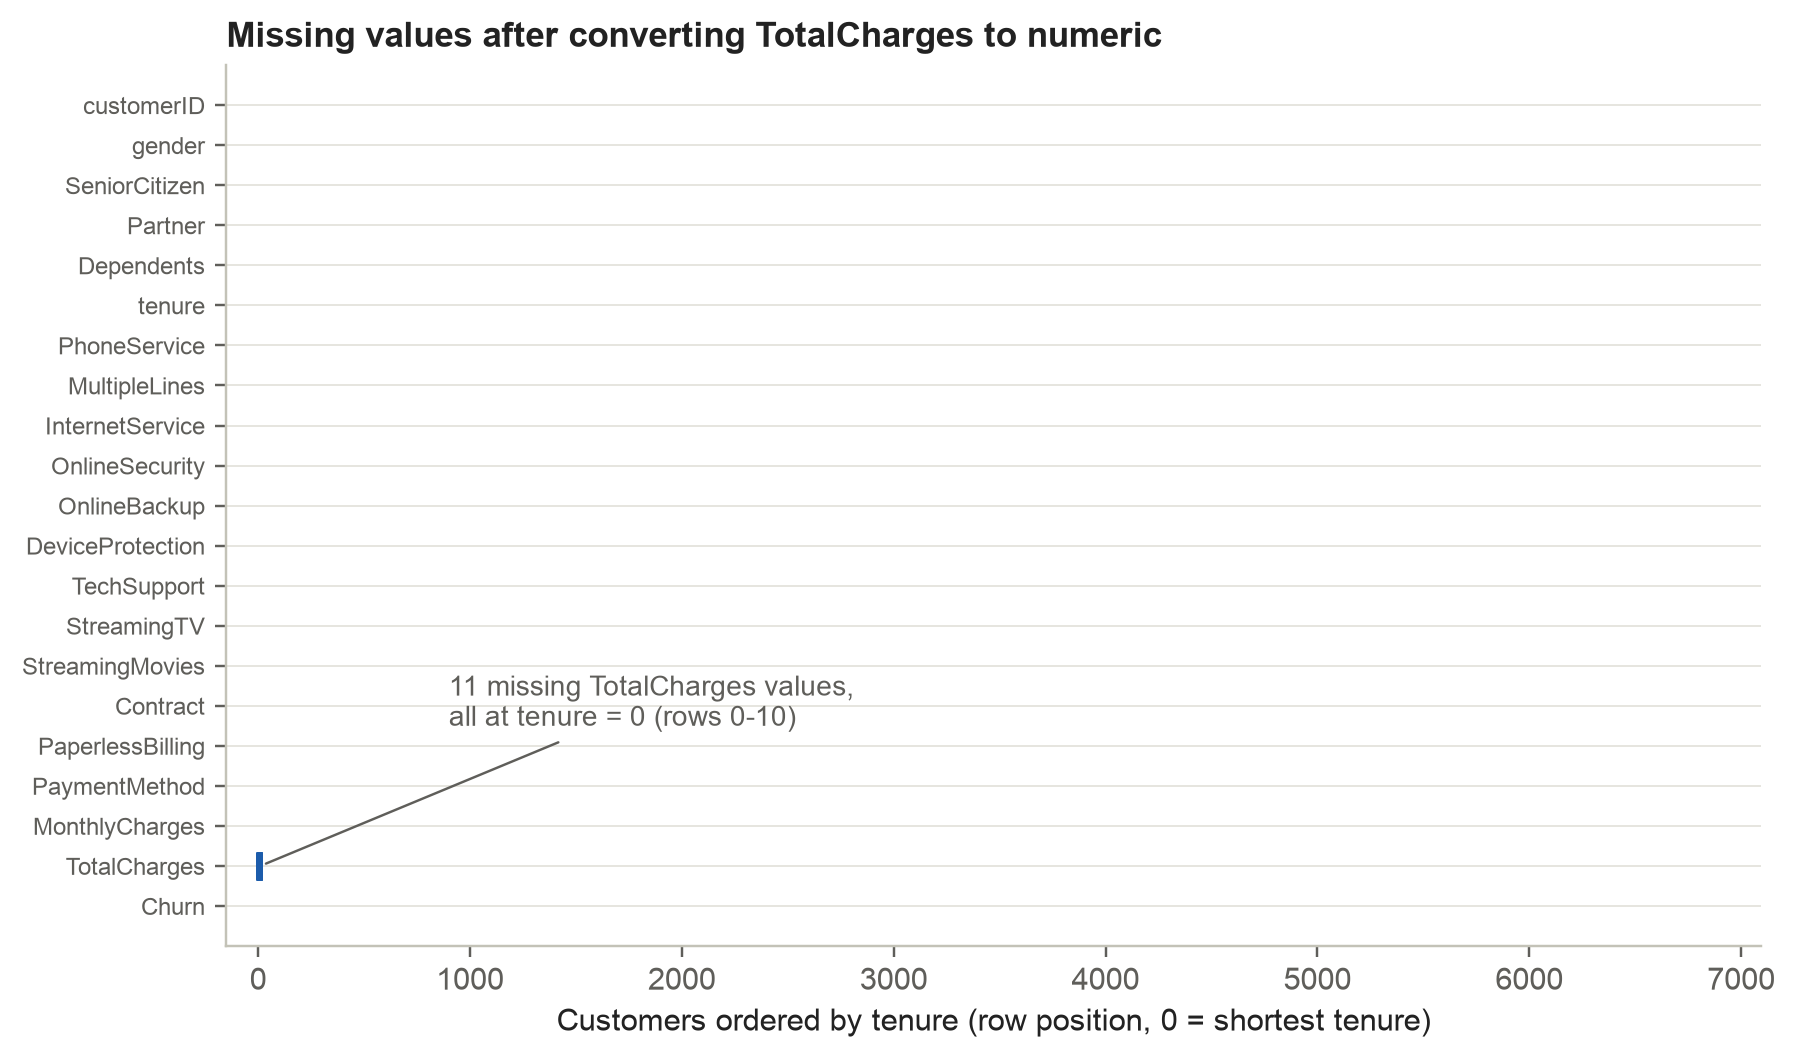

In [18]:
# Missingness map: every column, customers ordered by tenure (x axis)
order = df.sort_values("tenure", kind="stable").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 5.2))
for y_position, column in enumerate(order.columns):
    ax.axhline(y_position, color=GRID_COLOR, linewidth=0.6, zorder=0)
    missing_positions = np.flatnonzero(order[column].isna().to_numpy())
    ax.scatter(missing_positions, np.full(len(missing_positions), y_position),
               marker="|", s=90, linewidths=1.6, color=CHURN_COLOR, zorder=2)
ax.set_yticks(range(len(order.columns)))
ax.set_yticklabels(order.columns, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(-150, len(order) + 50)
ax.grid(False)
ax.set_xlabel("Customers ordered by tenure (row position, 0 = shortest tenure)")
ax.set_title("Missing values after converting TotalCharges to numeric")
ax.annotate("11 missing TotalCharges values,\nall at tenure = 0 (rows 0-10)",
            xy=(10, list(order.columns).index("TotalCharges")),
            xytext=(900, list(order.columns).index("TotalCharges") - 3.5),
            fontsize=9, color=MUTED_INK,
            arrowprops=dict(arrowstyle="-", color=MUTED_INK, linewidth=0.8))
save_figure(fig, "fig1_1_missing_value_map.png")

**Treatment.** All 11 customers with a blank `TotalCharges` have `tenure = 0`
and no other customer has `tenure = 0`, so the values are missing because
these accounts have not completed a billing month yet. Their accumulated
charges are therefore set to 0. Dropping the rows or filling with the median
(about $1,400) were rejected - the median would give brand-new accounts a
billing history they do not have.

In [19]:
total_charges_before = df["TotalCharges"].describe()

fill_mask = df["TotalCharges"].isna() & zero_tenure
df.loc[fill_mask, "TotalCharges"] = 0.0

total_charges_after = df["TotalCharges"].describe()
impact = pd.DataFrame({"before (NaN excluded)": total_charges_before,
                       "after (filled with 0)": total_charges_after}).round(2)
display(impact)
print("Remaining missing values:", int(df.isna().sum().sum()))

,before (NaN excluded),after (filled with 0)
count,7032.00,7043.00
mean,2283.30,2279.73
std,2266.77,2266.79
min,18.80,0.00
25%,401.45,398.55
50%,1397.48,1394.55
75%,3794.74,3786.60
max,8684.80,8684.80


Remaining missing values: 0


In [20]:
# Save the before/after evidence and log the counts for the report
missing_before_after = pd.DataFrame({
    "raw_nan": df_raw.isna().sum(),
    "raw_blank_strings": pd.Series(blank_strings).reindex(df_raw.columns).fillna(0).astype(int),
    "after_type_conversion": missing_after_conversion["missing_count"],
    "after_treatment": df.isna().sum(),
})
missing_before_after.to_csv(TABLE_DIR / "missing_values_before_after.csv")
impact.to_csv(TABLE_DIR / "totalcharges_imputation_impact.csv")

cleaning_log["missing"] = {
    "raw_nan_cells": int(df_raw.isna().sum().sum()),
    "blank_string_columns": blank_strings,
    "missing_after_conversion": int(df["TotalCharges"].isna().sum() + fill_mask.sum()),
    "missing_rows_all_tenure_zero": bool(df_raw.loc[converted.isna(), "tenure"].eq(0).all()),
    "tenure_zero_rows": int(zero_tenure.sum()),
    "missing_rows_churn_values": df_raw.loc[converted.isna(), "Churn"].value_counts().to_dict(),
    "missing_rows_contract_values": df_raw.loc[converted.isna(), "Contract"].value_counts().to_dict(),
    "filled_with_zero": int(fill_mask.sum()),
    "missing_after_treatment": int(df.isna().sum().sum()),
    "totalcharges_mean_before": round(float(total_charges_before["mean"]), 2),
    "totalcharges_mean_after": round(float(total_charges_after["mean"]), 2),
    "totalcharges_median_before": round(float(total_charges_before["50%"]), 2),
    "totalcharges_median_after": round(float(total_charges_after["50%"]), 2),
}

### 2.4 Duplicate records

In [21]:
full_row_duplicates = int(df.duplicated().sum())
duplicate_ids = int(df["customerID"].duplicated().sum())
profile_duplicates = int(df.drop(columns="customerID").duplicated().sum())
rows_in_profile_groups = int(df.drop(columns="customerID").duplicated(keep=False).sum())

print("Fully duplicated rows            :", full_row_duplicates)
print("Duplicated customerID values     :", duplicate_ids)
print("Rows repeating another customer's")
print("  attributes when ID is ignored  :", profile_duplicates,
      f"(involving {rows_in_profile_groups} rows)")

Fully duplicated rows            : 0
Duplicated customerID values     : 0
Rows repeating another customer's
  attributes when ID is ignored  : 22 (involving 42 rows)


In [22]:
# What do the same-profile rows look like? Distinct IDs, identical attributes.
attribute_columns = [c for c in df.columns if c != "customerID"]
profile_groups = df[df.duplicated(subset=attribute_columns, keep=False)]
display(profile_groups.sort_values(attribute_columns).head(6))
display(profile_groups[["tenure", "MonthlyCharges"]].describe().round(2))

cleaning_log["duplicates"] = {
    "full_row_duplicates": full_row_duplicates,
    "duplicate_customer_ids": duplicate_ids,
    "profile_duplicates_excluding_id": profile_duplicates,
    "rows_in_profile_duplicate_groups": rows_in_profile_groups,
    "profile_duplicates_max_tenure": int(profile_groups["tenure"].max()),
    "profile_duplicates_internet_service": profile_groups["InternetService"].value_counts().to_dict(),
    "rows_removed": 0,
}

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,9728-FTTVZ,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,7660-HDPJV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,4702-IOQDC,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,0328-GRPMV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,2619-WFQWU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,9985-MWVIX,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes


,tenure,MonthlyCharges
count,42.0,42.00
mean,1.0,36.73
std,0.0,22.37
min,1.0,19.55
25%,1.0,20.11
50%,1.0,20.45
75%,1.0,69.20
max,1.0,70.15


No duplicate records exist: every row has its own `customerID` and no row is
repeated in full. The 22 rows that match another row once the ID is ignored
belong to different customers on very common, simple plans (short tenure,
identical price), so they are kept.

### 2.5 Data quality checks: labels, whitespace, ranges and consistency

In [23]:
quality_checks = {}

# (a) Leading/trailing whitespace in text columns (after the TotalCharges fix)
text_columns = df.select_dtypes(exclude="number").columns
quality_checks["values_with_extra_whitespace"] = int(
    sum((df[c] != df[c].str.strip()).sum() for c in text_columns))

# (b) Labels that differ only by case or spacing (e.g. "Yes" vs "yes ")
case_conflicts = {c: int(df[c].nunique() - df[c].str.strip().str.lower().nunique())
                  for c in text_columns if c != "customerID"}
quality_checks["case_or_spacing_label_conflicts"] = int(sum(case_conflicts.values()))

# (c) Structural labels must agree with the parent service column
addon_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
no_internet = df["InternetService"].eq("No")
quality_checks["phone_label_inconsistencies"] = int(
    (df["PhoneService"].eq("No") != df["MultipleLines"].eq("No phone service")).sum())
quality_checks["internet_label_inconsistencies"] = int(sum(
    (no_internet != df[c].eq("No internet service")).sum() for c in addon_columns))

# (d) Impossible numeric values
quality_checks["negative_numeric_values"] = int((df[NUMERIC_COLUMNS] < 0).sum().sum())
quality_checks["non_positive_monthly_charges"] = int(df["MonthlyCharges"].le(0).sum())
quality_checks["totalcharges_below_monthly_when_tenure_ge_1"] = int(
    (df["tenure"].ge(1) & (df["TotalCharges"] < df["MonthlyCharges"] - 0.01)).sum())

display(pd.Series(quality_checks, name="count").to_frame())
display(df[NUMERIC_COLUMNS].agg(["min", "max"]).round(2))

,count
values_with_extra_whitespace,0
case_or_spacing_label_conflicts,0
phone_label_inconsistencies,0
internet_label_inconsistencies,0
negative_numeric_values,0
non_positive_monthly_charges,0
totalcharges_below_monthly_when_tenure_ge_1,0


,tenure,MonthlyCharges,TotalCharges
min,0,18.25,0.0
max,72,118.75,8684.8


In [24]:
# (e) Billing consistency: TotalCharges vs tenure x current MonthlyCharges.
# Differences are expected when prices changed during the customer's life.
billed = df[df["tenure"] > 0].copy()
billed["expected_total"] = billed["tenure"] * billed["MonthlyCharges"]
billed["ratio"] = billed["TotalCharges"] / billed["expected_total"]
display(billed["ratio"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3).to_frame())

deviation = (billed["ratio"] - 1).abs()
quality_checks["billing_deviation_over_10pct"] = int(deviation.gt(0.10).sum())
quality_checks["billing_deviation_over_25pct"] = int(deviation.gt(0.25).sum())
print("Customers whose TotalCharges differs from tenure x MonthlyCharges by >10%:",
      quality_checks["billing_deviation_over_10pct"])
print("... by >25%:", quality_checks["billing_deviation_over_25pct"])
display(billed.loc[deviation.nlargest(5).index,
                   ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "expected_total", "ratio"]].round(2))

,ratio
count,7032.000
mean,1.000
std,0.051
min,0.689
1%,0.855
5%,0.924
50%,1.000
95%,1.075
99%,1.159
max,1.573


Customers whose TotalCharges differs from tenure x MonthlyCharges by >10%: 381
... by >25%: 27


,customerID,tenure,MonthlyCharges,TotalCharges,expected_total,ratio
5595,2308-STERM,2,19.40,61.05,38.8,1.57
869,0323-XWWTN,3,26.40,121.25,79.2,1.53
5673,6260-XLACS,4,19.70,117.80,78.8,1.49
4689,2832-SCUCO,2,19.90,57.40,39.8,1.44
4634,9426-SXNHE,2,18.75,53.15,37.5,1.42


In [25]:
# (f) Outliers by the 1.5 x IQR rule - flagged, not removed
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

outlier_counts = {c: iqr_outlier_count(df[c]) for c in NUMERIC_COLUMNS}
print("IQR-rule outliers per numeric column:", outlier_counts)

cleaning_log["quality_checks"] = quality_checks
cleaning_log["quality_checks"]["iqr_outliers"] = outlier_counts
cleaning_log["quality_checks"]["billing_ratio_median"] = round(float(billed["ratio"].median()), 4)
cleaning_log["quality_checks"]["billing_ratio_p01"] = round(float(billed["ratio"].quantile(0.01)), 3)
cleaning_log["quality_checks"]["billing_ratio_p99"] = round(float(billed["ratio"].quantile(0.99)), 3)
cleaning_log["numeric_ranges"] = df[NUMERIC_COLUMNS].agg(["min", "max"]).round(2).to_dict()
pd.Series(quality_checks).to_csv(TABLE_DIR / "data_quality_checks.csv", header=["count"])

IQR-rule outliers per numeric column: {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


### 2.6 Data type corrections

In [26]:
dtypes_before = df_raw.dtypes.astype(str)
memory_before = df_raw.memory_usage(deep=True).sum()

# SeniorCitizen is a yes/no flag stored as 0/1; use the same labels as Partner etc.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Text columns with a small fixed set of values become pandas categories
for column in CATEGORICAL_COLUMNS:
    df[column] = df[column].astype("category")

# Numeric churn flag for correlations and modelling (1 = churned)
df["churn_flag"] = (df["Churn"] == "Yes").astype("int64")

dtype_changes = pd.DataFrame({"before": dtypes_before,
                              "after": df.dtypes.astype(str).reindex(dtypes_before.index)})
dtype_changes.loc["churn_flag"] = ["(new column)", str(df["churn_flag"].dtype)]
display(dtype_changes[dtype_changes["before"] != dtype_changes["after"]])
memory_after = df.memory_usage(deep=True).sum()
print(f"Memory: {memory_before / 1024:,.0f} KB -> {memory_after / 1024:,.0f} KB")

,before,after
gender,str,category
SeniorCitizen,int64,category
Partner,str,category
Dependents,str,category
PhoneService,str,category
MultipleLines,str,category
InternetService,str,category
OnlineSecurity,str,category
OnlineBackup,str,category
DeviceProtection,str,category


Memory: 7,975 KB -> 801 KB


In [27]:
dtype_changes.to_csv(TABLE_DIR / "dtype_changes.csv")
cleaning_log["dtypes"] = {
    "changed_columns": dtype_changes[dtype_changes["before"] != dtype_changes["after"]].to_dict("index"),
    "memory_kb_before": round(memory_before / 1024, 1),
    "memory_kb_after": round(memory_after / 1024, 1),
}

### 2.7 Save the cleaned dataset

In [28]:
df.to_csv(CLEAN_DATA_PATH, index=False)
cleaning_log["clean_shape"] = list(df.shape)
cleaning_log["rows_removed"] = int(df_raw.shape[0] - df.shape[0])

print("Raw shape  :", df_raw.shape)
print("Clean shape:", df.shape, "(churn_flag added)")
print("Missing values remaining:", int(df.isna().sum().sum()))
df.info()

with open(RESULTS_DIR / "cleaning_log.json", "w") as f:
    json.dump(cleaning_log, f, indent=2, default=str)
print("Saved data/processed/telco_churn_clean.csv and outputs/results/cleaning_log.json")

Raw shape  : (7043, 21)
Clean shape: (7043, 22) (churn_flag added)
Missing values remaining: 0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   ca

## Part 3 - Exploratory data analysis

Works on the cleaned file from Part 2. The questions are simple: how are the
numeric variables distributed, how common is churn, which customer groups
churn more often, and how strongly do the variables move together?

In [29]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from scipy.stats.contingency import association

from config import RESULTS_DIR, TABLE_DIR
from data_utils import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, load_clean_data
from plot_style import (CHURN_COLOR, MUTED_INK, RETAINED_COLOR, SEQUENTIAL_CMAP,
                        apply_style, save_figure)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
apply_style()

df = load_clean_data()
eda_summary = {}
print(df.shape)

(7043, 22)


### 3.1 Target variable: how many customers churned?

In [30]:
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
churn_rate = df["churn_flag"].mean()
display(pd.DataFrame({"customers": churn_counts,
                      "percent": (churn_counts / len(df) * 100).round(2)}))
print(f"Overall churn rate: {churn_rate:.2%}")
eda_summary["churn_counts"] = churn_counts.to_dict()
eda_summary["churn_rate"] = round(float(churn_rate), 4)

,customers,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


Overall churn rate: 26.54%


### 3.2 Numeric variables: central tendency and dispersion

In [31]:
numeric_stats = df[NUMERIC_COLUMNS].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T
numeric_stats["q1"] = df[NUMERIC_COLUMNS].quantile(0.25)
numeric_stats["q3"] = df[NUMERIC_COLUMNS].quantile(0.75)
numeric_stats["iqr"] = numeric_stats["q3"] - numeric_stats["q1"]
numeric_stats = numeric_stats[["count", "mean", "median", "std", "min", "q1", "q3", "iqr", "max", "skew"]]
display(numeric_stats.round(2))
numeric_stats.round(3).to_csv(TABLE_DIR / "numeric_descriptive_stats.csv")
eda_summary["numeric_stats"] = numeric_stats.round(3).to_dict("index")

,count,mean,median,std,min,q1,q3,iqr,max,skew
tenure,7043.0,32.37,29.00,24.56,0.00,9.00,55.00,46.00,72.00,0.24
MonthlyCharges,7043.0,64.76,70.35,30.09,18.25,35.50,89.85,54.35,118.75,-0.22
TotalCharges,7043.0,2279.73,1394.55,2266.79,0.00,398.55,3786.60,3388.05,8684.80,0.96


In [32]:
# Context for the shapes seen in the histograms below
tenure_1 = int((df["tenure"] == 1).sum())
tenure_72 = int((df["tenure"] == 72).sum())
print("Customers with tenure = 1 month  :", tenure_1)
print("Customers with tenure = 72 months:", tenure_72)
charges_by_internet = df.groupby("InternetService", observed=True)["MonthlyCharges"].describe().round(2)
display(charges_by_internet)
charges_by_internet.to_csv(TABLE_DIR / "monthly_charges_by_internet_service.csv")
eda_summary["tenure_1_count"] = tenure_1
eda_summary["tenure_72_count"] = tenure_72
eda_summary["monthly_charges_by_internet"] = charges_by_internet.to_dict("index")

Customers with tenure = 1 month  : 613
Customers with tenure = 72 months: 362


,count,mean,std,min,25%,50%,75%,max
InternetService,,,,,,,,
DSL,2421.0,58.10,16.26,23.45,46.20,56.15,69.90,94.80
Fiber optic,3096.0,91.50,12.66,67.75,80.55,91.68,101.15,118.75
No,1526.0,21.08,2.16,18.25,19.70,20.15,20.90,26.90


In [33]:
# The same statistics split by churn status
by_churn = df.groupby("Churn", observed=True)[NUMERIC_COLUMNS].agg(["mean", "median", "std"]).round(2)
display(by_churn)
by_churn.to_csv(TABLE_DIR / "numeric_stats_by_churn.csv")
eda_summary["numeric_by_churn"] = {
    status: {col: {"mean": float(by_churn.loc[status, (col, "mean")]),
                   "median": float(by_churn.loc[status, (col, "median")])}
             for col in NUMERIC_COLUMNS}
    for status in ["No", "Yes"]
}

tenure               MonthlyCharges               TotalCharges                  
        mean median    std           mean median    std         mean   median      std
Churn                                                                                 
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52  2329.95
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55  1890.82

Saved figure: outputs/figures/fig1_2_numeric_distributions.png


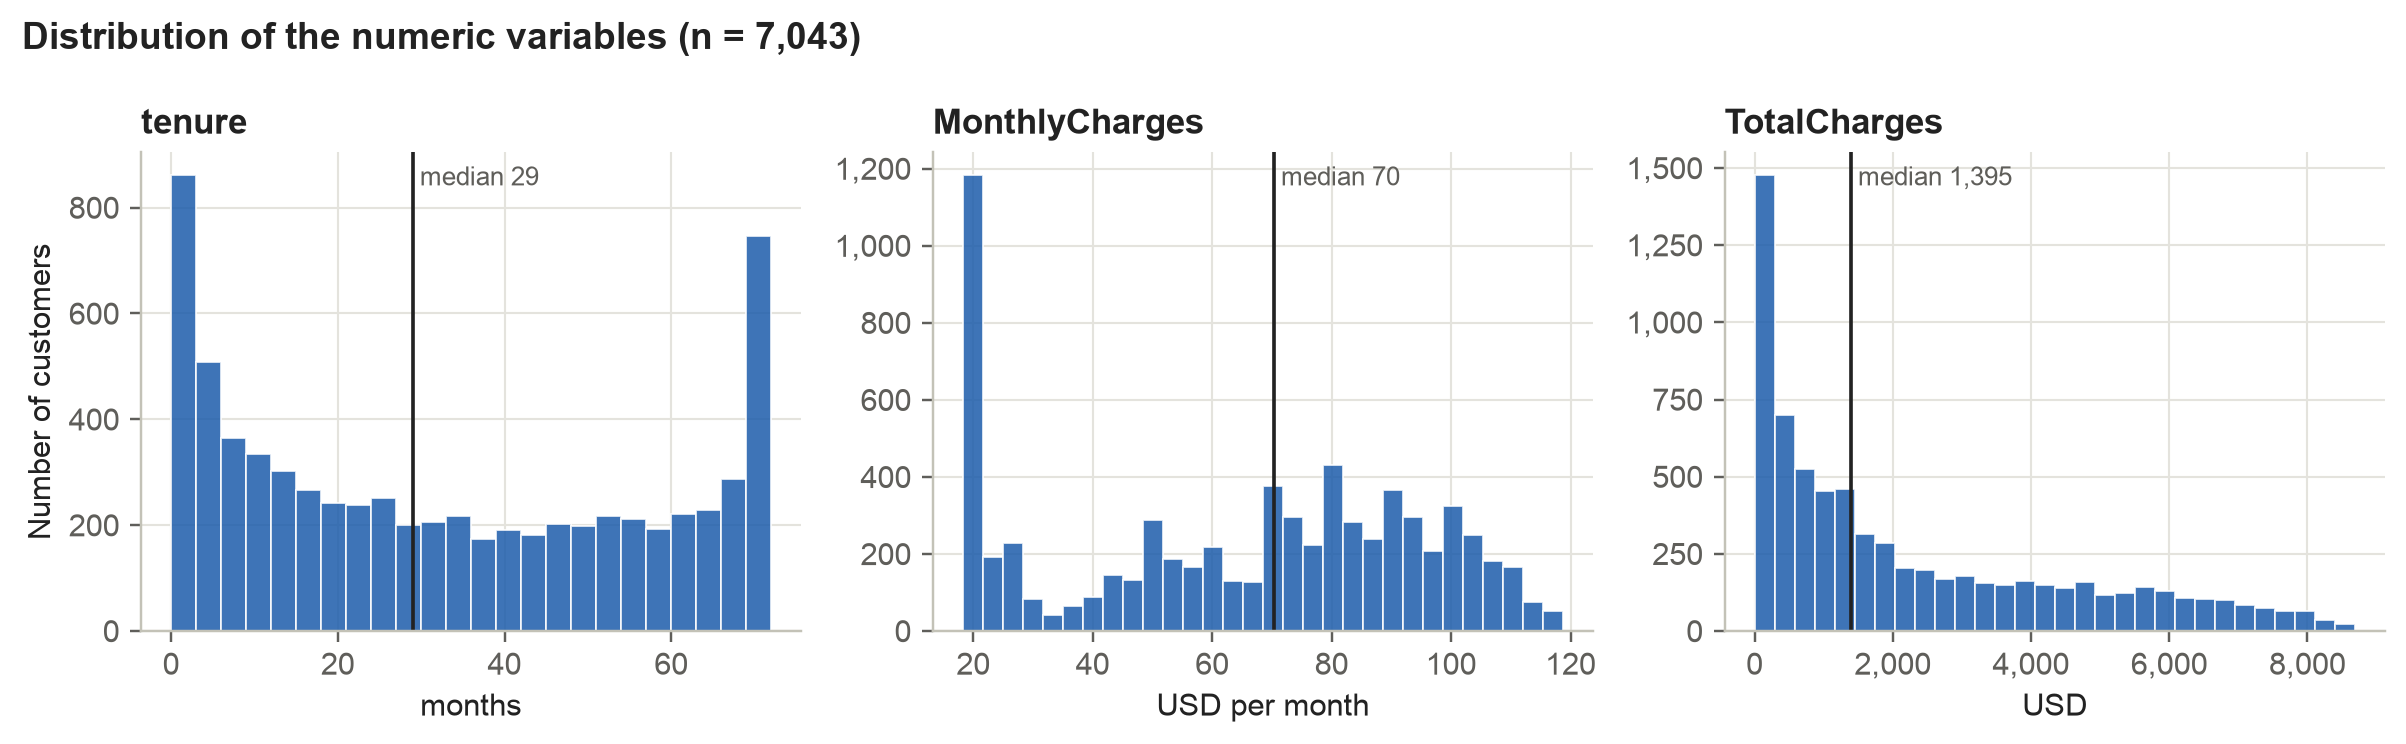

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
units = {"tenure": "months", "MonthlyCharges": "USD per month", "TotalCharges": "USD"}
bins = {"tenure": np.arange(0, 75, 3), "MonthlyCharges": 30, "TotalCharges": 30}
for ax, column in zip(axes, NUMERIC_COLUMNS):
    ax.hist(df[column], bins=bins[column], color=CHURN_COLOR, alpha=0.85,
            edgecolor="white", linewidth=0.6)
    median = df[column].median()
    ax.axvline(median, color="#222222", linewidth=1.2)
    ax.text(median, ax.get_ylim()[1] * 0.97, f" median {median:,.0f}", va="top",
            fontsize=8.5, color=MUTED_INK)
    ax.set_title(column)
    ax.set_xlabel(units[column])
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0].set_ylabel("Number of customers")
fig.suptitle("Distribution of the numeric variables (n = 7,043)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig1_2_numeric_distributions.png")

Saved figure: outputs/figures/fig1_3_numeric_by_churn_boxplots.png


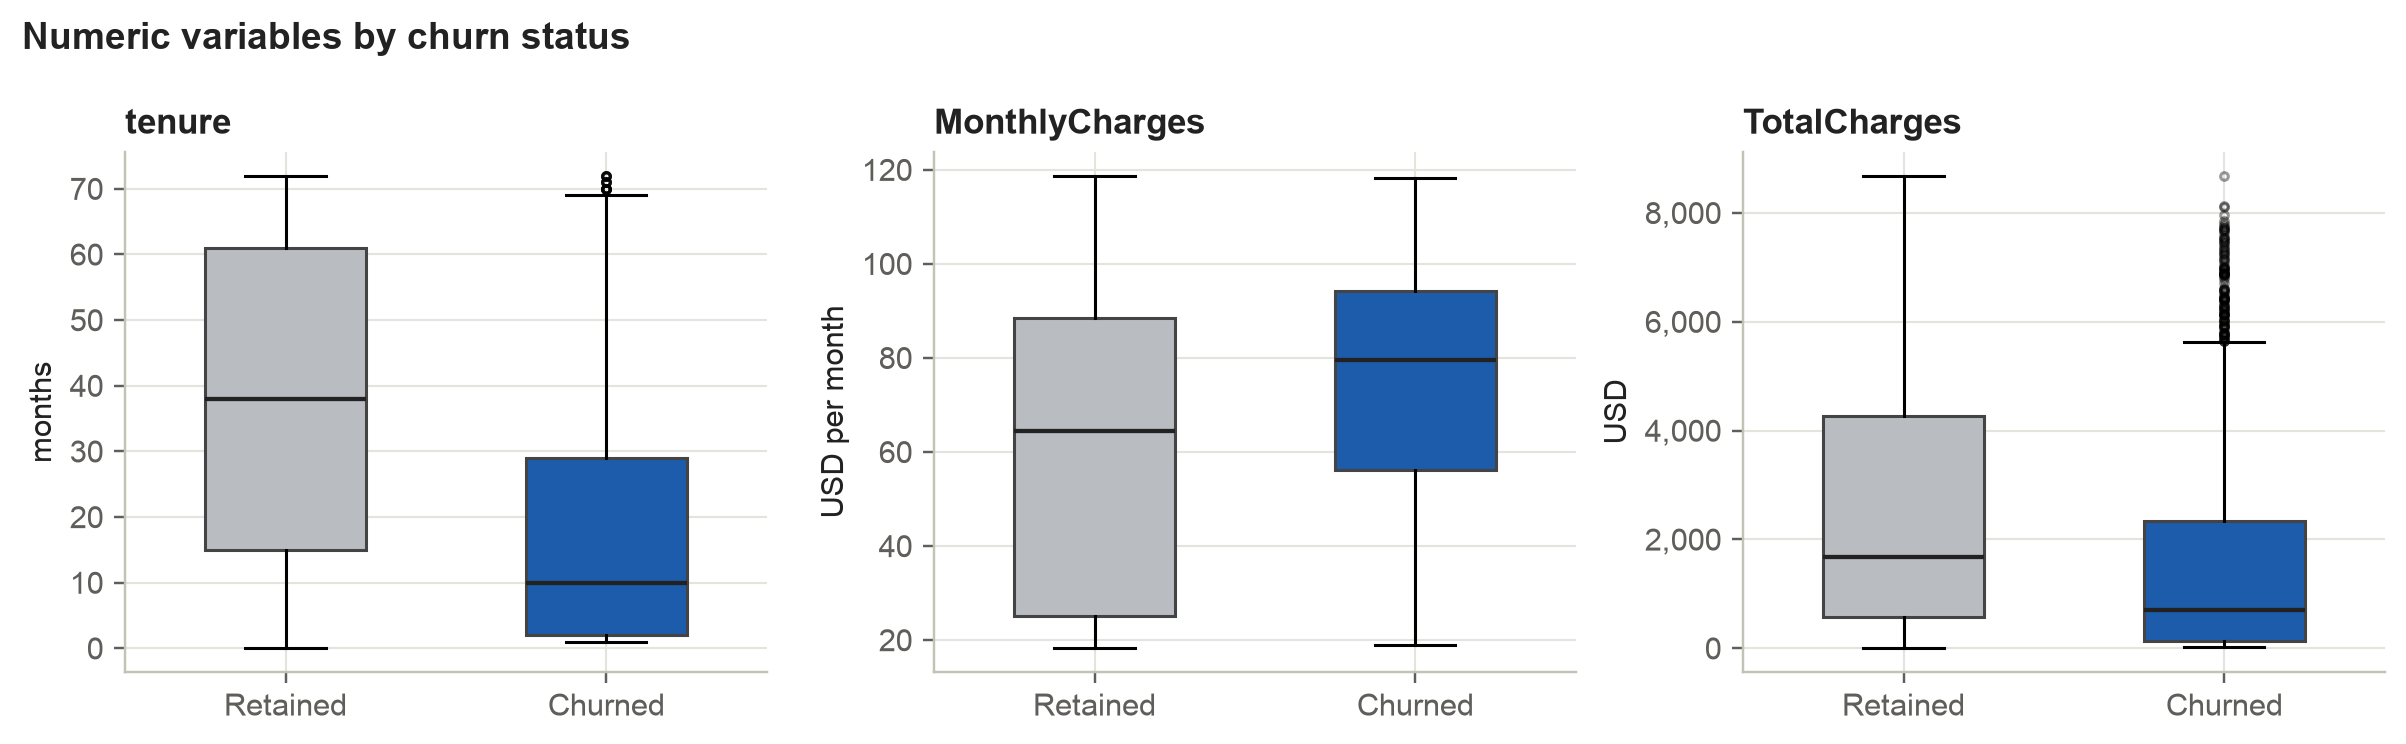

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, column in zip(axes, NUMERIC_COLUMNS):
    groups = [df.loc[df["Churn"] == s, column] for s in ["No", "Yes"]]
    box = ax.boxplot(groups, tick_labels=["Retained", "Churned"], widths=0.5,
                     patch_artist=True, medianprops=dict(color="#222222", linewidth=1.4),
                     flierprops=dict(marker="o", markersize=2.5, alpha=0.4))
    for patch, colour in zip(box["boxes"], [RETAINED_COLOR, CHURN_COLOR]):
        patch.set_facecolor(colour)
        patch.set_edgecolor("#444444")
    ax.set_title(column)
    ax.set_ylabel(units[column])
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.suptitle("Numeric variables by churn status", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig1_3_numeric_by_churn_boxplots.png")

### 3.3 Categorical variables: frequencies and churn rates

In [36]:
predictor_categoricals = [c for c in CATEGORICAL_COLUMNS if c != "Churn"]
rows = []
for column in predictor_categoricals:
    grouped = df.groupby(column, observed=True)["churn_flag"].agg(["size", "mean"])
    for category, (n, rate) in grouped.iterrows():
        rows.append({"variable": column, "category": category, "customers": int(n),
                     "share_pct": round(n / len(df) * 100, 2),
                     "churn_rate_pct": round(rate * 100, 2)})
category_table = pd.DataFrame(rows)
category_table.to_csv(TABLE_DIR / "churn_rate_by_category.csv", index=False)
display(category_table[category_table["variable"].isin(
    ["Contract", "InternetService", "PaymentMethod", "TechSupport", "SeniorCitizen"])])

,variable,category,customers,share_pct,churn_rate_pct
2,SeniorCitizen,No,5901,83.79,23.61
3,SeniorCitizen,Yes,1142,16.21,41.68
13,InternetService,DSL,2421,34.37,18.96
14,InternetService,Fiber optic,3096,43.96,41.89
15,InternetService,No,1526,21.67,7.40
25,TechSupport,No,3473,49.31,41.64
26,TechSupport,No internet service,1526,21.67,7.40
27,TechSupport,Yes,2044,29.02,15.17
34,Contract,Month-to-month,3875,55.02,42.71
35,Contract,One year,1473,20.91,11.27


Saved figure: outputs/figures/fig1_4_churn_rate_by_category.png


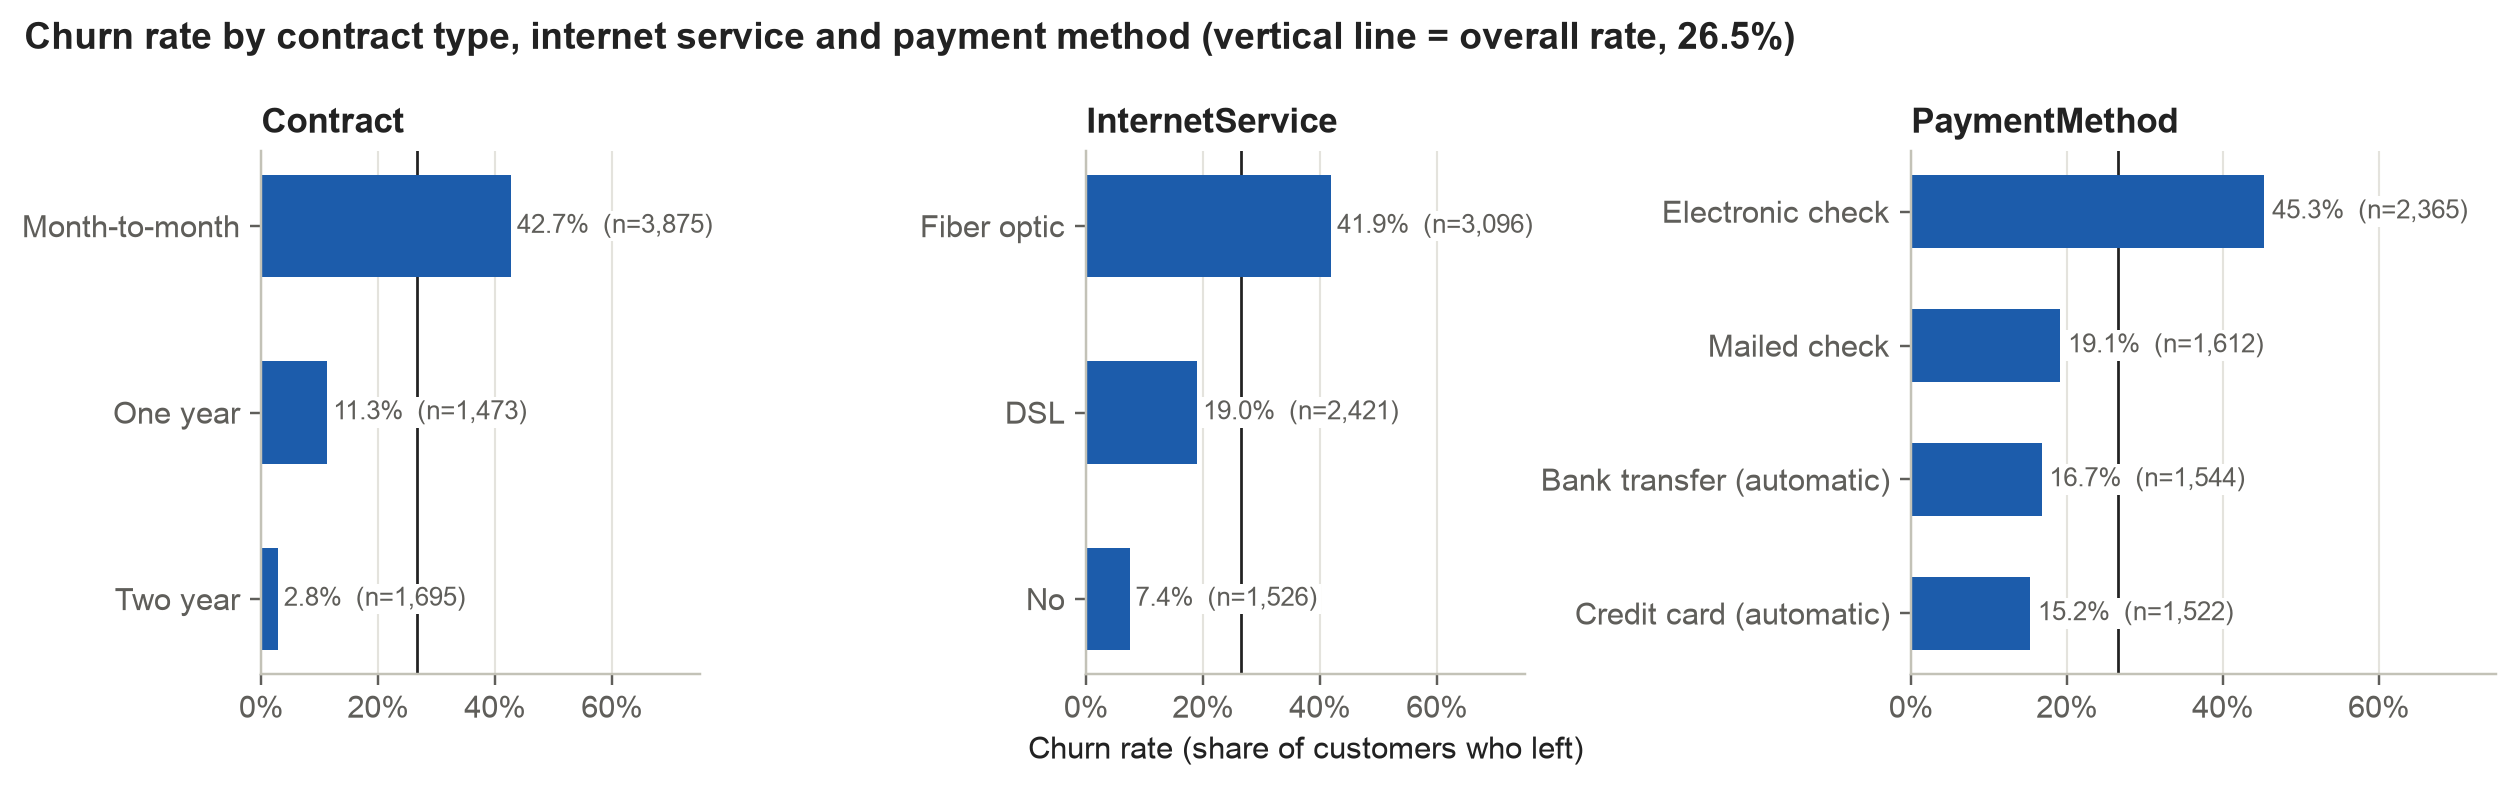

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), gridspec_kw={"width_ratios": [3, 3, 4]})
for ax, column in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    subset = category_table[category_table["variable"] == column].sort_values("churn_rate_pct")
    positions = np.arange(len(subset))
    ax.axvline(churn_rate * 100, color="#222222", linewidth=0.9, zorder=1)
    ax.barh(positions, subset["churn_rate_pct"], height=0.55, color=CHURN_COLOR, zorder=2)
    for y, (rate, n) in enumerate(zip(subset["churn_rate_pct"], subset["customers"])):
        ax.text(rate + 1, y, f"{rate:.1f}%  (n={n:,})", va="center", fontsize=8.5, color=MUTED_INK,
                zorder=3, bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
    ax.set_yticks(positions)
    ax.set_yticklabels(subset["category"])
    ax.set_xlim(0, 75)
    ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
    ax.set_title(column)
    ax.grid(axis="y", visible=False)
axes[1].set_xlabel("Churn rate (share of customers who left)")
fig.suptitle("Churn rate by contract type, internet service and payment method "
             f"(vertical line = overall rate, {churn_rate:.1%})",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig1_4_churn_rate_by_category.png")

eda_summary["churn_rate_by_category"] = {
    column: category_table[category_table["variable"] == column]
    .set_index("category")[["customers", "churn_rate_pct"]].to_dict("index")
    for column in predictor_categoricals
}

### 3.4 Churn across the customer lifecycle (tenure bands)

The data is a single snapshot, so there is no calendar time series. Tenure
is the closest thing to a time axis: it shows how churn differs between
newer and longer-standing customers.

In [38]:
tenure_bins = [-1, 12, 24, 36, 48, 60, 72]
tenure_labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df["tenure_band"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)
tenure_trend = df.groupby("tenure_band", observed=True)["churn_flag"].agg(["size", "mean"])
tenure_trend.columns = ["customers", "churn_rate"]
tenure_trend["churn_rate_pct"] = (tenure_trend["churn_rate"] * 100).round(2)
display(tenure_trend[["customers", "churn_rate_pct"]])
tenure_trend.to_csv(TABLE_DIR / "churn_rate_by_tenure_band.csv")
eda_summary["tenure_band_churn"] = tenure_trend[["customers", "churn_rate_pct"]].to_dict("index")

,customers,churn_rate_pct
tenure_band,,
0-12,2186,47.44
13-24,1024,28.71
25-36,832,21.63
37-48,762,19.03
49-60,832,14.42
61-72,1407,6.61


### 3.5 Relationships: correlations and association with churn

In [39]:
corr_columns = NUMERIC_COLUMNS + ["churn_flag"]
pearson = df[corr_columns].corr(method="pearson")
spearman = df[corr_columns].corr(method="spearman")
display(pearson.round(3))
display(spearman.round(3))
pearson.round(4).to_csv(TABLE_DIR / "correlation_pearson.csv")
spearman.round(4).to_csv(TABLE_DIR / "correlation_spearman.csv")
eda_summary["pearson"] = pearson.round(4).to_dict()
eda_summary["spearman"] = spearman.round(4).to_dict()

,tenure,MonthlyCharges,TotalCharges,churn_flag
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
churn_flag,-0.352,0.193,-0.198,1.000


,tenure,MonthlyCharges,TotalCharges,churn_flag
tenure,1.000,0.276,0.890,-0.367
MonthlyCharges,0.276,1.000,0.638,0.185
TotalCharges,0.890,0.638,1.000,-0.230
churn_flag,-0.367,0.185,-0.230,1.000


Saved figure: outputs/figures/fig1_5_correlation_heatmap.png


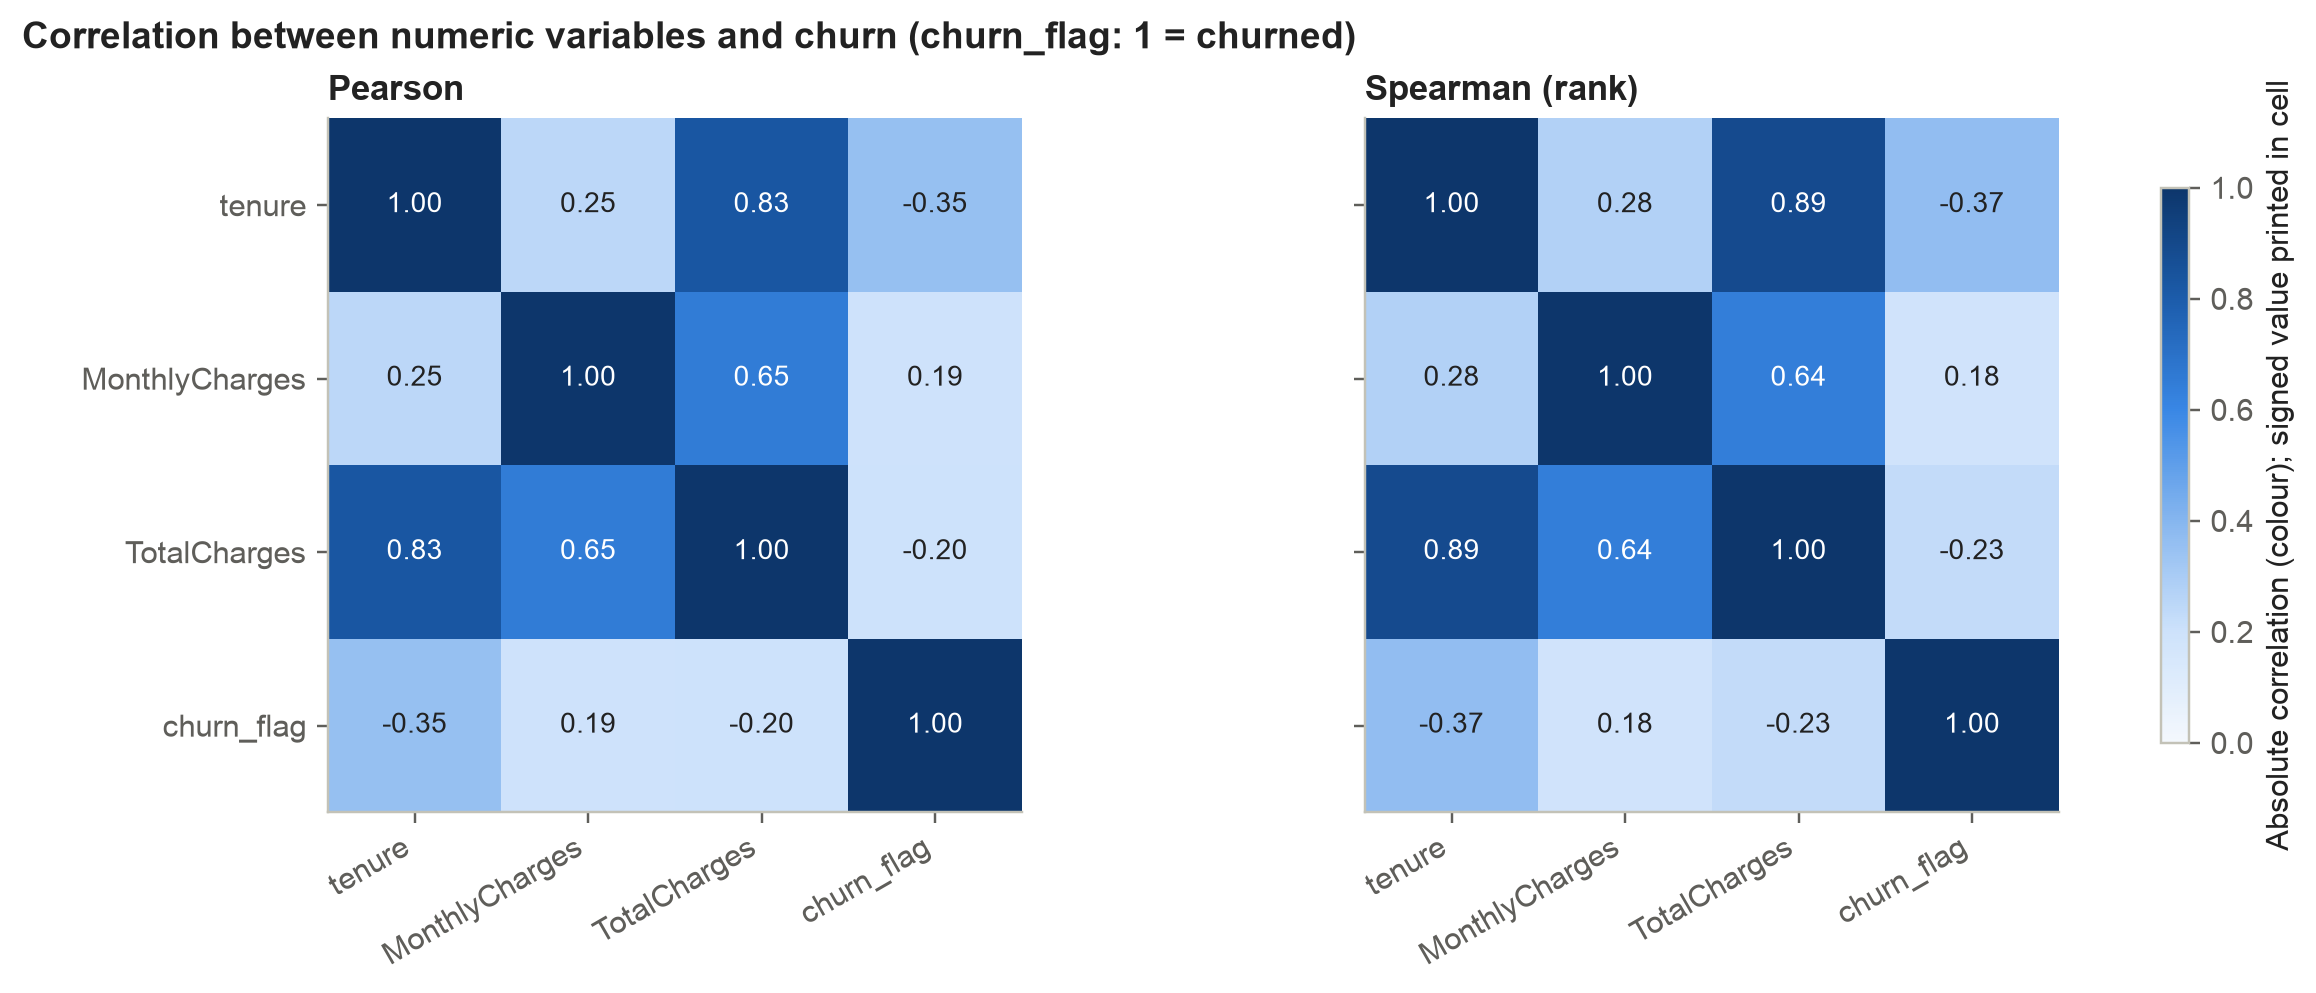

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), layout="constrained")
for ax, matrix, name in zip(axes, [pearson, spearman], ["Pearson", "Spearman (rank)"]):
    image = ax.imshow(matrix.abs(), cmap=SEQUENTIAL_CMAP, vmin=0, vmax=1)
    ax.set_xticks(range(len(corr_columns)))
    ax.set_yticks(range(len(corr_columns)))
    ax.set_xticklabels(corr_columns, rotation=30, ha="right")
    ax.set_yticklabels(corr_columns)
    for i in range(len(corr_columns)):
        for j in range(len(corr_columns)):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(value) > 0.55 else "#222222")
    ax.set_title(name)
    ax.grid(False)
axes[1].set_yticklabels([])
cbar = fig.colorbar(image, ax=axes, shrink=0.8)
cbar.set_label("Absolute correlation (colour); signed value printed in cell")
fig.suptitle("Correlation between numeric variables and churn (churn_flag: 1 = churned)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
save_figure(fig, "fig1_5_correlation_heatmap.png")

In [41]:
# Cramer's V: strength of association between each categorical variable and churn
# (0 = no association, 1 = perfect association)
cramers_v = {}
for column in predictor_categoricals:
    table = pd.crosstab(df[column], df["Churn"])
    cramers_v[column] = association(table.to_numpy(), method="cramer")
cramers_v = pd.Series(cramers_v).sort_values(ascending=False)
display(cramers_v.round(3).to_frame("cramers_v"))
cramers_v.round(4).to_csv(TABLE_DIR / "cramers_v_with_churn.csv", header=["cramers_v"])
eda_summary["cramers_v"] = cramers_v.round(4).to_dict()

,cramers_v
Contract,0.410
OnlineSecurity,0.347
TechSupport,0.343
InternetService,0.322
PaymentMethod,0.303
OnlineBackup,0.292
DeviceProtection,0.282
StreamingMovies,0.231
StreamingTV,0.231
PaperlessBilling,0.192


Saved figure: outputs/figures/fig1_6_cramers_v_association.png


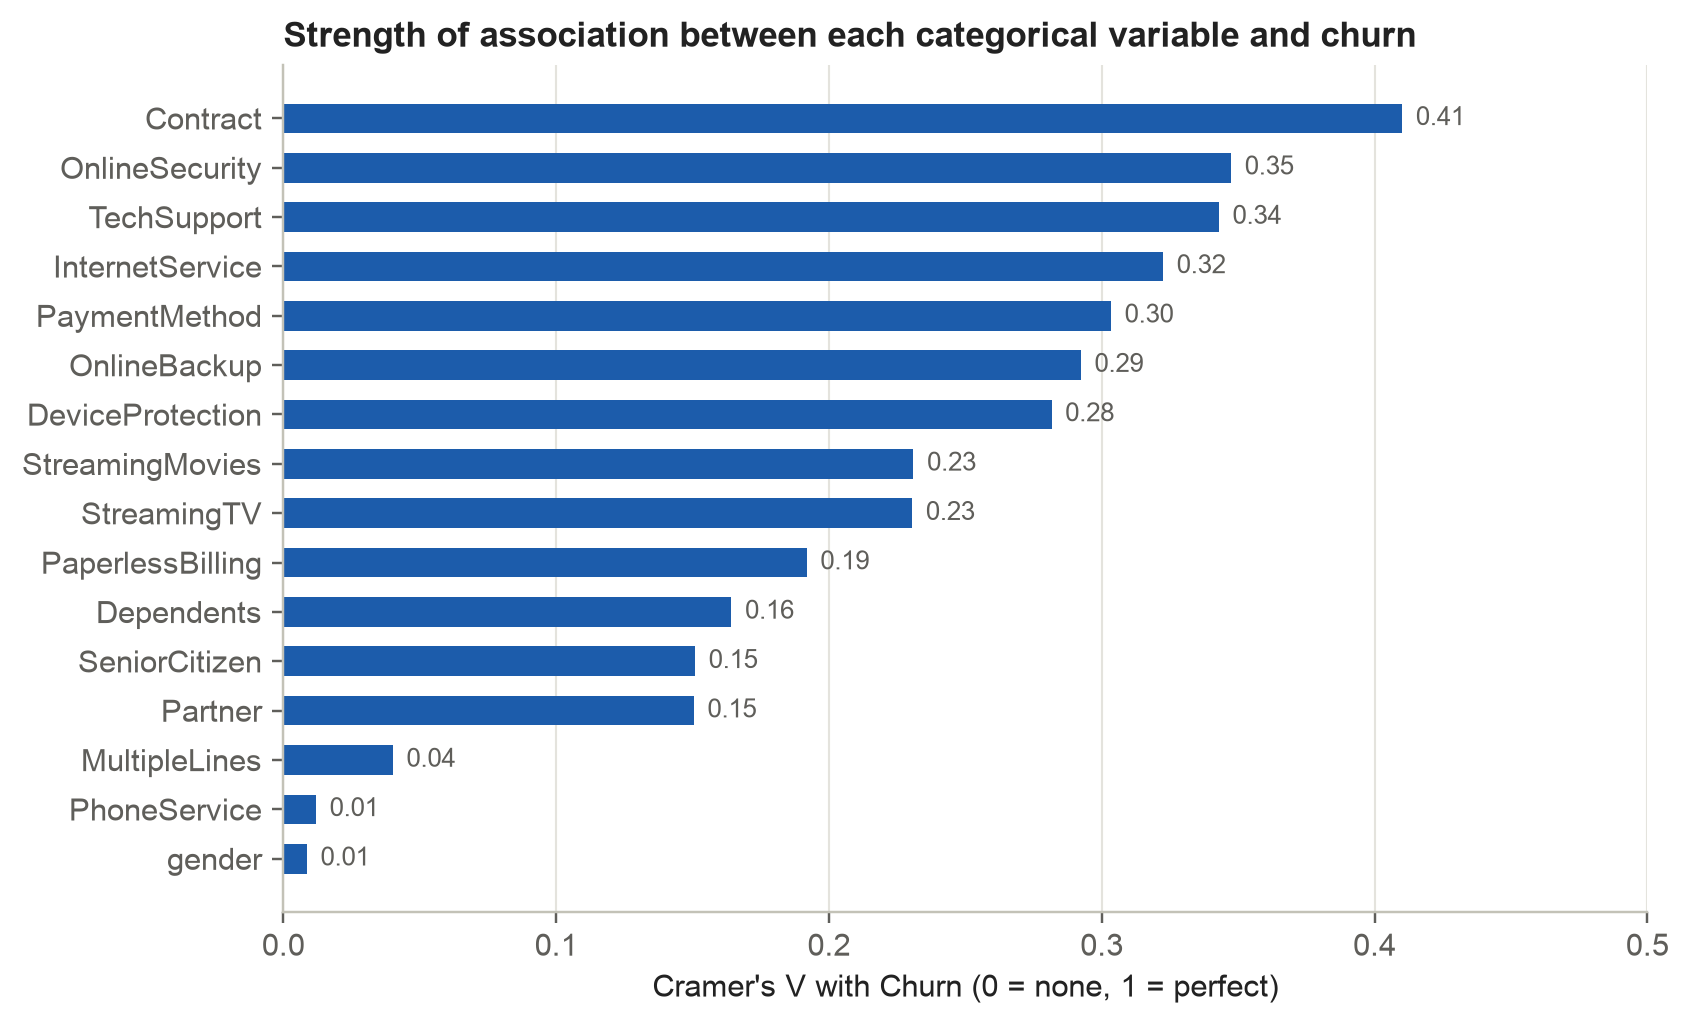

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
ordered = cramers_v.sort_values()
ax.barh(ordered.index, ordered.values, height=0.6, color=CHURN_COLOR)
for y, value in enumerate(ordered.values):
    ax.text(value + 0.005, y, f"{value:.2f}", va="center", fontsize=8.5, color=MUTED_INK)
ax.set_xlabel("Cramer's V with Churn (0 = none, 1 = perfect)")
ax.set_xlim(0, 0.5)
ax.grid(axis="y", visible=False)
ax.set_title("Strength of association between each categorical variable and churn")
save_figure(fig, "fig1_6_cramers_v_association.png")

In [43]:
with open(RESULTS_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2, default=str)
print("Saved outputs/results/eda_summary.json")

Saved outputs/results/eda_summary.json
